# Cellular vs free viral fractions, and lysogeny

In [11]:
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"]  = 42
mpl.rcParams["font.family"]  = "Arial"
from scipy.stats import mannwhitneyu, spearmanr, wilcoxon

MERGED_DF      = "/Users/skoog/Desktop/Final_WATL_wet_dry_merged_df.xlsx"
LYSOGENY_CALLS = "/Users/skoog/Desktop/lysogeny_calls.tsv"
HEADER_MAP     = "/Users/skoog/Desktop/WATL_wet_dry_viruses_header_map.tsv"
OUTDIR         = "/Users/skoog/Desktop/"

MISSING_PARTNER_LAKES = []   # dry lakes with no partner fraction sequenced
MIN_CONTIGS_FC  = 5          # min contigs for a family to enter the enrichment panel
MIN_N_PER_CLASS = 3          # min contigs for a lake x lysogeny median
PI_MAX_CONTIG   = 12         
PI_LIM_LAKE     = (4, 8)     

COL_CELL, COL_FREE, COL_BOTH, NEUTRAL = "#0766A4", "#0CA3A2", "#FFD300", "#33414D"
cat_order  = ["Cellular only", "Both", "Free only"]
DET_COLORS = {"Cellular only": COL_CELL, "Both": COL_BOTH, "Free only": COL_FREE}
LYSO       = ["No lysogeny evidence", "Temperate"]
LYSO_COL   = {LYSO[0]: COL_FREE, LYSO[1]: COL_CELL}
BOX_MED    = dict(color=NEUTRAL, linewidth=1.6)


def cliffs_delta(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    if len(a) < 1 or len(b) < 1:
        return np.nan, np.nan
    U, p = mannwhitneyu(a, b, alternative="two-sided")
    return 2.0 * U / (len(a) * len(b)) - 1.0, p


def cliff_label(d):
    if not np.isfinite(d):
        return "n/a"
    ad = abs(d)
    return ("negligible" if ad < 0.147 else "small" if ad < 0.33
            else "medium" if ad < 0.474 else "large")


def boxplot(ax, data, labels, **kw):
    # tick_labels replaced labels in mpl 3.9
    try:
        return ax.boxplot(data, tick_labels=labels, **kw)
    except TypeError:
        return ax.boxplot(data, labels=labels, **kw)


In [12]:
df = pd.read_excel(MERGED_DF)
print(f"{len(df):,} rows, {df['contig_id'].nunique():,} contigs, "
      f"{df.dropna(subset=['Average_pI'])['contig_id'].nunique():,} with pI")


19,509 rows, 11,786 contigs, 10,843 with pI


In [13]:
# abundance is 0.75 breadth for RPKM, so a row = detected
frac = df[df["Sample_Type"].isin(["DNA", "VIROME"])].copy()
frac["fraction"]  = frac["Sample_Type"].map({"DNA": "Cellular", "VIROME": "Free"})
frac["abundance"] = pd.to_numeric(frac["abundance"], errors="coerce")
frac = frac[(frac["abundance"] > 0) & ~frac["name_full"].isin(MISSING_PARTNER_LAKES)]

frac_cmp  = (frac.groupby(["name_full", "contig_id", "family", "fraction"], as_index=False)
                  ["abundance"].mean())
contig_pi = frac.dropna(subset=["Average_pI"]).groupby("contig_id", as_index=False)["Average_pI"].first()

frac_wide = (frac_cmp.pivot_table(index=["name_full", "contig_id", "family"],
                                  columns="fraction", values="abundance").reset_index())
for col in ("Cellular", "Free"):
    if col not in frac_wide:
        frac_wide[col] = np.nan
frac_wide["detection"] = np.select(
    [frac_wide["Cellular"].notna() & frac_wide["Free"].notna(),
     frac_wide["Cellular"].notna() & frac_wide["Free"].isna(),
     frac_wide["Cellular"].isna()  & frac_wide["Free"].notna()],
    ["Both", "Cellular only", "Free only"], default="none")
frac_wide = frac_wide.merge(contig_pi, on="contig_id", how="left")

# keep only lakes where both fractions cleared the breadth gate
lakes_paired = sorted(frac_wide.loc[frac_wide["detection"] == "Both", "name_full"].unique())
frac_wide   = frac_wide[frac_wide["name_full"].isin(lakes_paired)].reset_index(drop=True)
frac_paired = frac_cmp[frac_cmp["name_full"].isin(lakes_paired)].reset_index(drop=True)

def frac_cat(s):
    c, f = "Cellular" in s, "Free" in s
    return "Both" if (c and f) else ("Cellular only" if c else "Free only")

contig_cat = (frac_paired.groupby("contig_id")["fraction"].agg(set).map(frac_cat)
              .rename("frac_category").reset_index()
              .merge(contig_pi, on="contig_id", how="left"))

per_lake = (frac_wide.groupby(["name_full", "detection"]).size()
            .unstack(fill_value=0).reindex(columns=cat_order, fill_value=0))
per_lake["pct_shared"] = (100 * per_lake["Both"] / per_lake.sum(axis=1)).round(1)

print(f"{len(lakes_paired)} paired lakes of {frac['name_full'].nunique()} dry-season sites")
print(frac_wide["detection"].value_counts().to_dict())
print(per_lake.to_string())


3 paired lakes of 15 dry-season sites
{'Both': 1902, 'Free only': 1699, 'Cellular only': 317}
detection                 Cellular only  Both  Free only  pct_shared
name_full                                                           
Lake Gore (dry season)              129  1267       1252        47.8
Lake Warden (dry season)             41   531        447        52.1
Pink Lake  (dry season)             147   104          0        41.4


In [14]:
# family fraction preference and pI by fraction
fam_rpkm = frac_paired.groupby(["family", "fraction"])["abundance"].mean().unstack()
for col in ("Cellular", "Free"):
    if col not in fam_rpkm:
        fam_rpkm[col] = np.nan
fam_n = frac_paired.groupby("family")["contig_id"].nunique()
fc = fam_rpkm.loc[fam_n[fam_n >= MIN_CONTIGS_FC].index].copy()
fc["log2FC"] = np.log2(fc["Free"] / fc["Cellular"])
fc = fc.dropna(subset=["log2FC"]).sort_values("log2FC")

both     = frac_wide[frac_wide["detection"] == "Both"]
pis_frac = {c: contig_cat.loc[contig_cat["frac_category"] == c, "Average_pI"].dropna().values
            for c in cat_order}

print(f"{len(fc)} of {fam_n.size} families pass the {MIN_CONTIGS_FC}-contig cutoff")
print({c: round(float(np.median(pis_frac[c])), 3) for c in cat_order})
for g1, g2 in [("Cellular only", "Free only"), ("Cellular only", "Both"), ("Both", "Free only")]:
    d, p = cliffs_delta(pis_frac[g1], pis_frac[g2])
    print(f"{g1} vs {g2}: d={d:+.3f} ({cliff_label(d)}), p_adj={min(1.0, p*3):.3g}")


12 of 24 families pass the 5-contig cutoff
{'Cellular only': 5.647, 'Both': 5.632, 'Free only': 5.615}
Cellular only vs Free only: d=+0.017 (negligible), p_adj=1
Cellular only vs Both: d=+0.001 (negligible), p_adj=1
Both vs Free only: d=+0.014 (negligible), p_adj=1


In [15]:
# per-family table
det  = frac_paired.groupby(["family", "fraction"])["contig_id"].size().unstack(fill_value=0)
rpkm = frac_paired.groupby(["family", "fraction"])["abundance"].mean().unstack()
for name, tbl in (("det", det), ("rpkm", rpkm)):
    for col in ("Cellular", "Free"):
        if col not in tbl:
            tbl[col] = 0 if name == "det" else np.nan

fam_summary = pd.concat([
    frac_paired.groupby("family")["contig_id"].nunique().rename("n_contigs"),
    det.rename(columns={"Cellular": "n_detect_cellular", "Free": "n_detect_free"}),
    rpkm.rename(columns={"Cellular": "mean_RPKM_cellular", "Free": "mean_RPKM_free"}),
    frac_paired.merge(contig_pi, on="contig_id", how="left")
               .groupby("family")["Average_pI"].median().rename("median_pI"),
], axis=1).reset_index()
fam_summary["log2_free_over_cellular"] = np.log2(
    fam_summary["mean_RPKM_free"] / fam_summary["mean_RPKM_cellular"])
fam_summary = fam_summary.sort_values("n_contigs", ascending=False).reset_index(drop=True)
fam_summary.to_csv(OUTDIR + "SUPP_fraction_family_summary.csv", index=False)
fam_summary.head(12)


,family,n_contigs,n_detect_cellular,n_detect_free,mean_RPKM_cellular,mean_RPKM_free,median_pI,log2_free_over_cellular
0,Unclassified Caudoviricetes,3419,2098,3473,152.505484,118.550583,5.619268,-0.363358
1,Unclassified Kyanoviridae,32,19,31,118.598024,78.598827,4.943528,-0.593500
2,Phycodnaviridae,25,25,13,184.862960,55.178296,7.190740,-1.744283
3,Unclassified Autographiviridae,16,14,14,417.335985,535.458417,5.464811,0.359565
4,Unclassified Zobellviridae,12,6,11,127.868548,36.223603,6.157542,-1.819659
5,Iridoviridae,10,10,1,107.761514,9.398034,7.150748,-3.519339
6,Unclassified Demerecviridae,9,7,9,74.411678,18.762303,5.500335,-1.987692
7,Unclassified Megaviricetes,8,7,6,133.885176,35.589515,7.464091,-1.911472
8,Mimiviridae,7,7,3,39.742494,13.072315,6.519699,-1.604168
9,Unclassified Drexlerviridae,7,7,8,33.154662,25.872830,6.079692,-0.357774


In [16]:
# lysogeny calls. contig_id here is NODE_* / genomad_k141_*; CheckV uses WATLvirus_*. the header map bridges them but stores tool prefixes and suffixes (genomad_k141_x|provirus_2_25626), so both sides get normalized.
lyso_tbl  = pd.read_csv(LYSOGENY_CALLS, sep="\t")
all_watl  = set(lyso_tbl["contig_id"])

def base_name(s):
    return (s.astype(str)
             .str.replace(r"^(genomad|virsorter2?|vs2|checkv|dramv)_", "", regex=True)
             .str.replace(r"\|\|.*$", "", regex=True)
             .str.replace(r"\|provirus.*$", "", regex=True)
             .str.replace(r"-cat_\d+$", "", regex=True)
             .str.replace(".faa", "", regex=False)
             .str.strip())

hm = pd.read_csv(HEADER_MAP, sep="\t", header=None, names=["watl_id", "orig_id"],
                 dtype=str).dropna()
hm["base"] = base_name(hm["orig_id"])
hm["genomad_split"] = hm["orig_id"].str.contains(r"\|provirus", regex=True)
hm = hm.merge(lyso_tbl[["contig_id", "checkv_provirus", "integrase_present"]],
              left_on="watl_id", right_on="contig_id", how="left")
for col in ("checkv_provirus", "integrase_present"):
    hm[col] = hm[col].fillna(False).astype(bool)
hm["assessed"] = hm["watl_id"].isin(all_watl)

# one contig can appear by more than one tool, so collapse on the base name
base_calls = (hm.groupby("base")
              .agg(assessed=("assessed", "any"),
                   checkv_provirus=("checkv_provirus", "any"),
                   integrase_present=("integrase_present", "any"),
                   genomad_split=("genomad_split", "any")).reset_index())
base_calls["is_provirus"] = base_calls[
    ["checkv_provirus", "integrase_present", "genomad_split"]].any(axis=1)
base_calls["n_sources"] = base_calls[
    ["checkv_provirus", "integrase_present", "genomad_split"]].sum(axis=1)

contigs = pd.Series(df["contig_id"].dropna().unique(), name="contig_id")
cbase   = base_name(contigs)
ns      = cbase.str.extract(r"^([A-Za-z0-9]+_)")[0].fillna("other")

lookup = pd.DataFrame({"contig_id": contigs.values, "base": cbase.values}).merge(
    base_calls, on="base", how="left")
for col in ("assessed", "checkv_provirus", "integrase_present", "genomad_split", "is_provirus"):
    lookup[col] = lookup[col].fillna(False).astype(bool)
lookup["n_sources"] = lookup["n_sources"].fillna(0).astype(int)

df = df.merge(lookup[["contig_id", "assessed", "is_provirus", "n_sources",
                      "checkv_provirus", "integrase_present", "genomad_split"]],
              on="contig_id", how="left")
for col in ("assessed", "is_provirus", "checkv_provirus", "integrase_present", "genomad_split"):
    df[col] = df[col].fillna(False).astype(bool)
df["n_sources"] = df["n_sources"].fillna(0).astype(int)
df["lysogeny"]  = np.where(df["is_provirus"], LYSO[1], LYSO[0])
contig_cat["assessed"] = contig_cat["contig_id"].map(
    df.groupby("contig_id")["assessed"].max()).fillna(False)

uniq = df.drop_duplicates("contig_id")
print(pd.DataFrame({"ns": ns.values, "matched": lookup["assessed"].values})
      .groupby("ns")["matched"].agg(n="size", matched="sum",
                                    pct=lambda x: round(100 * x.mean(), 1)).to_string())
print(f"temperate {int(uniq['is_provirus'].sum())}, "
      f"with pI {int(uniq.loc[uniq['is_provirus'], 'Average_pI'].notna().sum())}")


          n  matched   pct
ns                        
NODE_  7616     6779  89.0
k141_  4170      110   2.6
temperate 393, with pI 347


In [17]:
len_by_base = (hm.merge(lyso_tbl[["contig_id", "contig_length"]],
                        left_on="watl_id", right_on="contig_id",
                        how="left", suffixes=("", "_l"))
                 .groupby("base")["contig_length"].max())

chk = (df[df["assessed"]].drop_duplicates("contig_id")
       [["contig_id", "is_provirus", "checkv_provirus", "integrase_present",
         "genomad_split", "family", "Average_pI"]].copy())
chk["length"] = base_name(chk["contig_id"]).map(len_by_base)

d_len, p_len = cliffs_delta(chk.loc[chk["is_provirus"], "length"].dropna(),
                            chk.loc[~chk["is_provirus"], "length"].dropna())
print(f"median length {chk.loc[chk['is_provirus'], 'length'].median():,.0f} vs "
      f"{chk.loc[~chk['is_provirus'], 'length'].median():,.0f} bp, "
      f"d={d_len:+.3f} ({cliff_label(d_len)}), p={p_len:.3g}")

q = chk.dropna(subset=["length", "Average_pI"]).copy()
q["bin"] = pd.qcut(q["length"], 4, labels=["Q1", "Q2", "Q3", "Q4"])
rows = []
for b, g in q.groupby("bin", observed=True):
    a = g.loc[g["is_provirus"], "Average_pI"].values
    o = g.loc[~g["is_provirus"], "Average_pI"].values
    d, p = cliffs_delta(a, o)
    rows.append({"length_quartile": str(b), "median_length_bp": round(float(g["length"].median())),
                 "n_temperate": len(a), "n_other": len(o),
                 "median_pI_temperate": round(float(np.median(a)), 3),
                 "median_pI_other": round(float(np.median(o)), 3),
                 "cliffs_delta": round(d, 3), "effect": cliff_label(d), "MW_p": p})
length_strat = pd.DataFrame(rows)
length_strat.to_csv(OUTDIR + "SUPP_lysogeny_pI_length_stratified.csv", index=False)
length_strat


median length 7,407 vs 5,269 bp, d=+0.432 (medium), p=1e-32


,length_quartile,median_length_bp,n_temperate,n_other,median_pI_temperate,median_pI_other,cliffs_delta,effect,MW_p
0,Q1,3868,14,1460,5.963,5.493,0.127,negligible,0.413025
1,Q2,4812,35,1441,5.355,5.559,-0.119,negligible,0.229334
2,Q3,6200,61,1411,5.966,5.569,0.063,negligible,0.406512
3,Q4,8736,113,1361,6.070,5.689,0.171,small,0.002507


In [18]:
# only contigs that carry a call, so the reference group is tested-and-negative
assessed = df[df["assessed"]]
contig_env = (assessed.dropna(subset=["Average_pI"]).groupby("contig_id")
              .agg(Average_pI=("Average_pI", "first"), name_full=("name_full", "first"),
                   pH=("pH", "mean"), Salinity=("Salinity", "mean"),
                   is_provirus=("is_provirus", "max")).reset_index())
contig_env["lysogeny"] = np.where(contig_env["is_provirus"], LYSO[1], LYSO[0])
pis_lyso = {k: contig_env.loc[contig_env["lysogeny"] == k, "Average_pI"].dropna().values
            for k in LYSO}

lake_lyso = (contig_env.groupby(["name_full", "lysogeny"])
             .agg(median_pI=("Average_pI", "median"), n=("Average_pI", "size"),
                  pH=("pH", "first")).reset_index())
lake_lyso = lake_lyso[lake_lyso["n"] >= MIN_N_PER_CLASS]
lw = lake_lyso.pivot(index="name_full", columns="lysogeny", values="median_pI")
for k in LYSO:
    if k not in lw:
        lw[k] = np.nan
lw_both = lw.dropna(subset=LYSO)

lyso_d, lyso_p = cliffs_delta(pis_lyso[LYSO[1]], pis_lyso[LYSO[0]])
wil_dif = float((lw_both[LYSO[1]] - lw_both[LYSO[0]]).median()) if len(lw_both) >= 5 else np.nan
wil_p   = wilcoxon(lw_both[LYSO[1]], lw_both[LYSO[0]]).pvalue if len(lw_both) >= 5 else np.nan

ph_fits = {}
for k in LYSO:
    d_ = lake_lyso[lake_lyso["lysogeny"] == k].dropna(subset=["pH", "median_pI"])
    ph_fits[k] = np.polyfit(d_["pH"], d_["median_pI"], 1) if len(d_) >= 4 else None

print(f"{len(contig_env):,} assessed contigs with pI "
      f"({int(contig_env['is_provirus'].sum())} temperate, {len(lw_both)} paired lakes)")
print(f"median pI {np.median(pis_lyso[LYSO[0]]):.3f} vs {np.median(pis_lyso[LYSO[1]]):.3f}, "
      f"d={lyso_d:+.3f} ({cliff_label(lyso_d)}), p={lyso_p:.3g}")
print(f"within-lake difference {wil_dif:+.3f}, Wilcoxon p={wil_p:.3g}")
for k in LYSO:
    d_ = lake_lyso[lake_lyso["lysogeny"] == k].dropna(subset=["pH", "median_pI"])
    if ph_fits[k] is not None:
        rho, pp = spearmanr(d_["pH"], d_["median_pI"])
        print(f"{k}: slope {ph_fits[k][0]:+.3f}, rho {rho:+.2f}, p={pp:.3g}, {len(d_)} lakes")


6,020 assessed contigs with pI (347 temperate, 17 paired lakes)
median pI 5.587 vs 6.171, d=+0.189 (small), p=3.36e-09
within-lake difference +0.322, Wilcoxon p=0.0797
No lysogeny evidence: slope -0.095, rho -0.23, p=0.203, 33 lakes
Temperate: slope -0.137, rho -0.35, p=0.11, 22 lakes


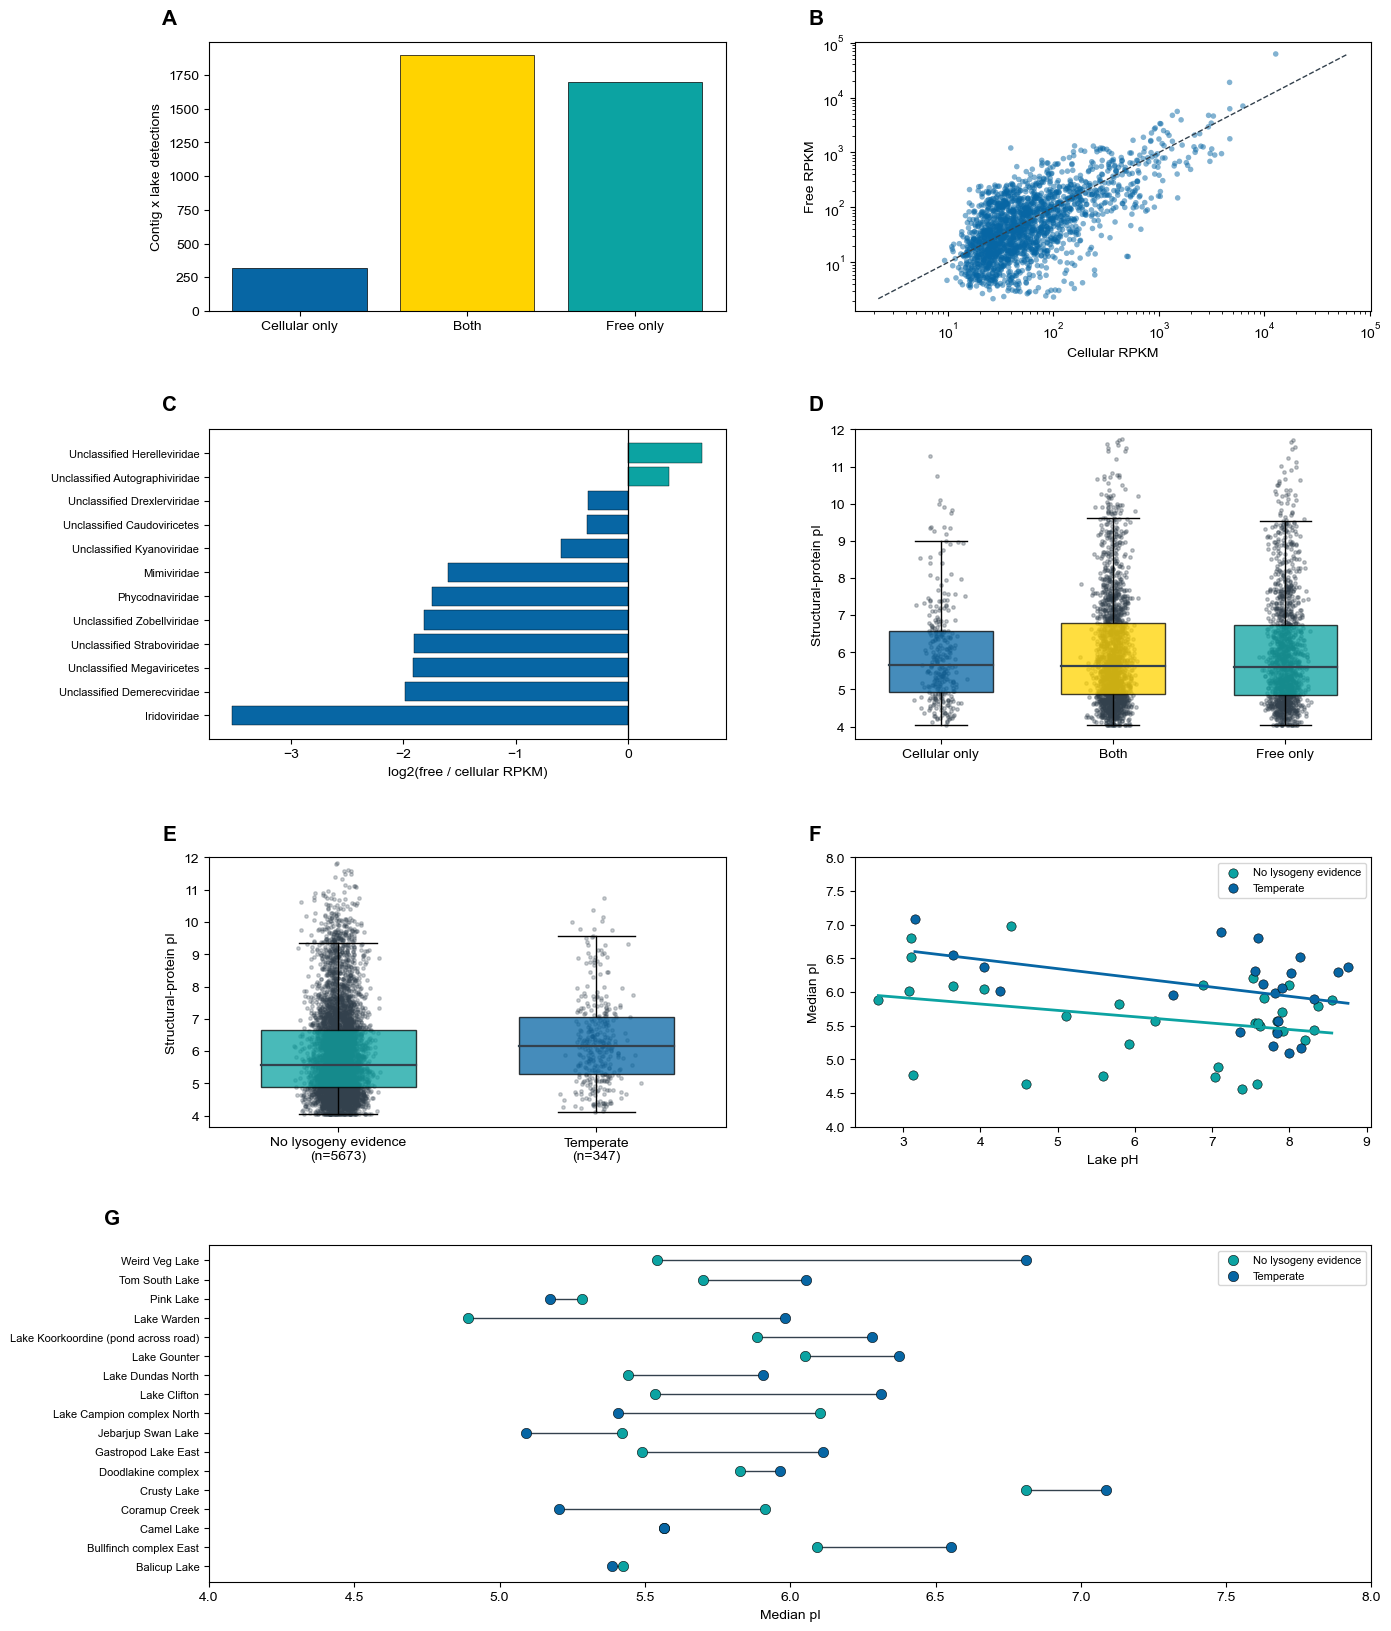

In [19]:
jit = np.random.default_rng(0)
fig = plt.figure(figsize=(15, 20))
gs  = GridSpec(4, 2, figure=fig, hspace=0.40, wspace=0.25,
               height_ratios=[1.0, 1.15, 1.0, 1.25])
axA, axB = fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])
axC, axD = fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])
axE, axF = fig.add_subplot(gs[2, 0]), fig.add_subplot(gs[2, 1])
axG = fig.add_subplot(gs[3, :])

for ax, letter in zip([axA, axB, axC, axD, axE, axF, axG], "ABCDEFG"):
    ax.text(-0.09, 1.05, letter, transform=ax.transAxes, fontsize=15,
            fontweight="bold", va="bottom")

dc = frac_wide["detection"].value_counts().reindex(cat_order).fillna(0)
axA.bar(cat_order, dc.values, color=[DET_COLORS[c] for c in cat_order],
        edgecolor="black", linewidth=0.5)
axA.set_ylabel("Contig x lake detections")

axB.scatter(both["Cellular"], both["Free"], s=16, alpha=0.5, color=COL_CELL,
            edgecolor="none", rasterized=True)
lo = float(np.nanmin([both["Cellular"].min(), both["Free"].min()]))
hi = float(np.nanmax([both["Cellular"].max(), both["Free"].max()]))
axB.plot([lo, hi], [lo, hi], "--", color=NEUTRAL, lw=1)
axB.set_xscale("log"); axB.set_yscale("log")
axB.set_xlabel("Cellular RPKM"); axB.set_ylabel("Free RPKM")

axC.barh(np.arange(len(fc)), fc["log2FC"].values,
         color=[COL_FREE if v > 0 else COL_CELL for v in fc["log2FC"]],
         edgecolor="black", linewidth=0.3)
axC.set_yticks(np.arange(len(fc))); axC.set_yticklabels(fc.index, fontsize=8)
axC.axvline(0, color="black", lw=0.9)
axC.set_xlabel("log2(free / cellular RPKM)")

bp = boxplot(axD, [pis_frac[c] for c in cat_order], cat_order,
             showfliers=False, widths=0.6, patch_artist=True, medianprops=BOX_MED)
for patch, c in zip(bp["boxes"], cat_order):
    patch.set_facecolor(DET_COLORS[c]); patch.set_alpha(0.75)
for i, c in enumerate(cat_order, 1):
    axD.scatter(jit.normal(i, 0.05, len(pis_frac[c])), pis_frac[c], s=6, alpha=0.3,
                color=NEUTRAL, rasterized=True)
axD.set_ylim(axD.get_ylim()[0], PI_MAX_CONTIG)
axD.set_ylabel("Structural-protein pI")

bp = boxplot(axE, [pis_lyso[k] for k in LYSO], [f"{k}\n(n={len(pis_lyso[k])})" for k in LYSO],
             showfliers=False, widths=0.6, patch_artist=True, medianprops=BOX_MED)
for patch, k in zip(bp["boxes"], LYSO):
    patch.set_facecolor(LYSO_COL[k]); patch.set_alpha(0.75)
for i, k in enumerate(LYSO, 1):
    axE.scatter(jit.normal(i, 0.05, len(pis_lyso[k])), pis_lyso[k], s=6, alpha=0.25,
                color=NEUTRAL, rasterized=True)
axE.set_ylim(axE.get_ylim()[0], PI_MAX_CONTIG)
axE.set_ylabel("Structural-protein pI")

for k in LYSO:
    d_ = lake_lyso[lake_lyso["lysogeny"] == k].dropna(subset=["pH", "median_pI"])
    axF.scatter(d_["pH"], d_["median_pI"], s=45, color=LYSO_COL[k],
                edgecolor="black", linewidth=0.4, label=k)
    if ph_fits[k] is not None:
        xs = np.linspace(d_["pH"].min(), d_["pH"].max(), 50)
        axF.plot(xs, ph_fits[k][1] + ph_fits[k][0] * xs, color=LYSO_COL[k], lw=2)
axF.set_xlabel("Lake pH"); axF.set_ylabel("Median pI")
axF.set_ylim(*PI_LIM_LAKE)
axF.legend(fontsize=8)

ys = np.arange(len(lw_both))
for i, (_, row) in enumerate(lw_both.iterrows()):
    axG.plot([row[LYSO[0]], row[LYSO[1]]], [i, i], "-", color=NEUTRAL, lw=1, zorder=1)
for k in LYSO:
    axG.scatter(lw_both[k], ys, s=55, color=LYSO_COL[k], edgecolor="black",
                linewidth=0.4, zorder=2, label=k)
axG.set_yticks(ys); axG.set_yticklabels(lw_both.index, fontsize=8)
axG.set_xlabel("Median pI")
axG.set_xlim(*PI_LIM_LAKE)
axG.legend(fontsize=8)

for ext in ("svg", "pdf", "png"):
    plt.savefig(f"{OUTDIR}SUPP_fraction_and_lysogeny.{ext}", dpi=300, bbox_inches="tight")
plt.show()
